# Exploratory Data Analysis — Professional Workflow
**NAVTTC · Data Analytics Using Python**

---

## What is EDA?

EDA is a **structured investigation** of your data before drawing any conclusions.  
Most beginners jump straight to charts. Professionals follow a fixed sequence — because the order prevents mistakes.

```
PHASE 1 — UNDERSTAND    What columns do I have? What types? What size?
PHASE 2 — AUDIT         What is broken, missing, or suspicious?
PHASE 3 — CLEAN         Fix it. Document every decision.
PHASE 4 — ANALYSE       Answer questions with numbers first.
PHASE 5 — VISUALISE     Turn the numbers into charts.
PHASE 6 — TEST          Is the pattern real or random? (Statistics)
PHASE 7 — CONCLUDE      Write what the data is saying.
```

Skipping any phase means your conclusions may be built on dirty data.

---

**Dataset:** `ecommerce_orders.csv` — 515 Pakistani e-commerce orders, Jan 2023 – Jun 2024

**Known messiness (intentional):**
- Mixed-case city names with trailing spaces
- `unit_price` stored as string — some rows have `Rs.` prefix
- 3 rows with negative quantity (data entry error)
- 3 rows with zero price
- 8 missing customer names
- 54 missing ratings
- 10 exact duplicate rows

In [1]:
%pip install scipy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings

warnings.filterwarnings('ignore')

# Seaborn theme — set once, applies to all charts
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams['figure.facecolor'] = 'white'

pd.set_option('display.max_columns',None)
pd.set_option('display.max_rows', None)
pd.set_option('display.float_format', '{:,.2f}'.format)

print('Ready.')

Ready.


---
# PHASE 1 — UNDERSTAND
## Load and Profile: Know What You Have

Load the raw file. Do not change anything yet. Read it first.

In [3]:
raw = pd.read_csv('ecommerce_orders_raw.csv')

print(f'Rows:    {raw.shape[0]}')
print(f'Columns: {raw.shape[1]}')
print(f'Memory:  {raw.memory_usage(deep=True).sum() / 1024:.1f} KB')
print()
raw.head()

Rows:    515
Columns: 11
Memory:  278.3 KB



,order_id,customer_name,city,category,product,quantity,unit_price,payment_method,order_status,order_date,rating
0,1100,Fatima Farooq,Peshawar,Food & Grocery,Cooking Oil 5L,3,1750,Bank Transfer,Delivered,2023-07-25,4.00
1,1065,Ahmed Butt,Rawalpindi,Clothing,Jeans,4,3200,EasyPaisa,Cancelled,2024-05-17,5.00
2,1019,Nadia Nawaz,Multan,Home & Kitchen,Non-Stick Pan,1,2250,JazzCash,Processing,2024-02-25,5.00
3,1246,Faisal Sheikh,Islamabad,Electronics,USB Cable,2,350,JazzCash,Delivered,2024-02-23,5.00
4,1302,Bilal Ahmed,Rawalpindi,Health & Beauty,Hair Oil,5,350,JazzCash,Shipped,2023-06-28,3.00


In [4]:
# info() — the most useful single command for profiling
# Tells you: column names, non-null count (missing = rows where non-null < total), dtype
# Anything with dtype=object that should be a number is a data type problem

raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 515 entries, 0 to 514
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        515 non-null    int64  
 1   customer_name   507 non-null    str    
 2   city            515 non-null    str    
 3   category        515 non-null    str    
 4   product         515 non-null    str    
 5   quantity        515 non-null    int64  
 6   unit_price      515 non-null    str    
 7   payment_method  515 non-null    str    
 8   order_status    515 non-null    str    
 9   order_date      509 non-null    str    
 10  rating          461 non-null    float64
dtypes: float64(1), int64(2), str(8)
memory usage: 44.4 KB


In [5]:
# describe() — statistical summary for numeric columns
# Read this BEFORE plotting — it tells you the range, center, and spread

raw.describe().round(2)

,order_id,quantity,rating
count,515.00,515.00,461.00
mean,"1,326.87",3.10,4.47
std,783.94,1.48,0.64
min,"1,001.00",-5.00,3.00
25%,"1,127.50",2.00,4.00
50%,"1,253.00",3.00,5.00
75%,"1,377.50",4.00,5.00
max,"9,145.00",5.00,5.00


In [6]:
# Understand categorical columns — what unique values exist?
# Always do this — it often reveals typos and inconsistencies

for col in ['city', 'category', 'payment_method', 'order_status']:
    vals = sorted(raw[col].dropna().unique())
    print(f'{col}  ({len(vals)} unique):')
    print(f'  {vals}')
    print()

city  (18 unique):
  [' Rawalpindi', ' gujranwala', 'FAISALABAD', 'Faisalabad', 'Gujranwala', 'Islamabad', 'Karachi', 'LAHORE', 'Lahore', 'Multan', 'Peshawar', 'Quetta', 'Rawalpindi', 'Sialkot', 'islamabad ', 'karachi', 'peshawar ', 'quetta']

category  (8 unique):
  ['Books & Stationery', 'Clothing', 'Electronics', 'Food & Grocery', 'Health & Beauty', 'Home & Kitchen', 'Sports', 'Toys']

payment_method  (6 unique):
  ['Bank Transfer', 'Cash on Delivery', 'Credit Card', 'Debit Card', 'EasyPaisa', 'JazzCash']

order_status  (5 unique):
  ['Cancelled', 'Delivered', 'Processing', 'Returned', 'Shipped']



---
# PHASE 2 — AUDIT
## Find Every Problem Before Fixing Anything

**Rule:** Document problems first, fix them second.  
If you fix without documenting, you cannot explain your decisions to a client or manager.

In [7]:
# PROBLEM 1 — Missing values

missing = raw.isnull().sum()
missing_pct = (missing / len(raw) * 100).round(1)

audit_missing = pd.DataFrame({
    'missing_count': missing,
    'missing_%':     missing_pct
}).query('missing_count > 0')

print('Columns with missing values:')
print(audit_missing)
print(f'\nTotal missing: {missing.sum()} cells out of {raw.size}')

Columns with missing values:
               missing_count  missing_%
customer_name              8       1.60
order_date                 6       1.20
rating                    54      10.50

Total missing: 68 cells out of 5665


In [8]:
# PROBLEM 2 — Wrong data types
# unit_price is stored as object (string) — it should be a number
# order_date is stored as object (string) — it should be datetime

print('unit_price stored as:', raw['unit_price'].dtype)
print()

# Some rows have 'Rs.' prefix — this is why it is a string
rs_rows = raw[raw['unit_price'].astype(str).str.contains('Rs\.', regex=True)]
print(f'Rows with Rs. prefix: {len(rs_rows)}')
print(rs_rows[['customer_name', 'product', 'unit_price']].head(5).to_string())
print()

space_rows = raw[raw['unit_price'].astype(str).str.startswith(' ')]
print(f'Rows with leading space in price: {len(space_rows)}')

unit_price stored as: str

Rows with Rs. prefix: 15
       customer_name       product unit_price
94   Faisal Siddiqui  Puzzle 500pc     Rs.950
102      Usman Ahmed   Storage Box     Rs.850
123    Hassan Sheikh   Moisturizer     Rs.650
150   Ayesha Hussain    Urdu Novel     Rs.450
191       Sara Iqbal      Football    Rs.2100

Rows with leading space in price: 10


In [9]:
# PROBLEM 3 — Inconsistent string formatting in city column

print('Raw city values:')
print(sorted(raw['city'].unique()))
print()
raw_unique   = raw['city'].nunique()
fixed_unique = raw['city'].str.strip().str.title().nunique()
print(f'Raw unique cities:       {raw_unique}')
print(f'After strip + title:     {fixed_unique}')
print(f'Phantom duplicates:      {raw_unique - fixed_unique}  (same city, different case)')

Raw city values:
[' Rawalpindi', ' gujranwala', 'FAISALABAD', 'Faisalabad', 'Gujranwala', 'Islamabad', 'Karachi', 'LAHORE', 'Lahore', 'Multan', 'Peshawar', 'Quetta', 'Rawalpindi', 'Sialkot', 'islamabad ', 'karachi', 'peshawar ', 'quetta']

Raw unique cities:       18
After strip + title:     10
Phantom duplicates:      8  (same city, different case)


In [10]:
# PROBLEM 4 — Invalid numerical values

# Negative quantity — physically impossible
neg_qty = raw[raw['quantity'] < 0]
print(f'Negative quantity rows: {len(neg_qty)}')
print(neg_qty[['customer_name', 'product', 'quantity', 'unit_price']].to_string())
print()

# Zero price — could be error or a free item; investigate
temp_price = pd.to_numeric(
    raw['unit_price'].astype(str).str.replace('Rs.', '', regex=False).str.strip(),
    errors='coerce'
)
zero_price = raw[temp_price == 0]
print(f'Zero unit_price rows: {len(zero_price)}')
print(zero_price[['product', 'category', 'unit_price']].to_string())

Negative quantity rows: 3
     customer_name         product  quantity unit_price
16    Ayesha Nawaz       Vitamin C        -2        950
64    Amna Qureshi  Shalwar Kameez        -5       2700
96  Hassan Qureshi      Remote Car        -4       2700

Zero unit_price rows: 3
        product         category unit_price
7     Face Wash  Health & Beauty          0
66     Lego Set             Toys          0
307  Board Game             Toys          0


In [11]:
# PROBLEM 5 — Exact duplicate rows

n_dupes = raw.duplicated().sum()
print(f'Exact duplicate rows: {n_dupes}')

if n_dupes > 0:
    dupes = raw[raw.duplicated(keep=False)]
    print(dupes[['order_id', 'customer_name', 'product', 'order_date']].head(6).to_string())

Exact duplicate rows: 10
     order_id   customer_name          product  order_date
15       1388    Junaid Iqbal   Shalwar Kameez  2023-07-24
23       1335  Saima Siddiqui         Hair Oil  2023-02-08
131      1112   Shahid Farooq       Board Game  2023-11-05
140      1227     Waqas Malik             Iron  2024-05-14
141      1202     Fatima Raza  English Grammar  2023-05-01
144      1357     Omar Ansari      Moisturizer         NaN


In [12]:
# AUDIT SUMMARY — printed report before any fix is applied

print('=' * 65)
print('DATA QUALITY AUDIT REPORT')
print('=' * 65)
print(f'  {"Problem":<32}  {"Detail":<15}  Decision')
print('-' * 65)
problems = [
    ('Missing: customer_name',  f'{raw["customer_name"].isnull().sum()} rows',
     'Fill with "Unknown"'),
    ('Missing: order_date',
     f'{raw["order_date"].isnull().sum()} rows',
     'Drop — unusable without date'),
    ('Missing: rating',
     f'{raw["rating"].isnull().sum()} rows',
     'Keep NaN — field is optional'),
    ('Wrong type: unit_price',  'object',
     'Strip Rs. → pd.to_numeric()'),
    ('Wrong type: order_date',  'object',
     'pd.to_datetime()'),
    ('Formatting: city',        'mixed case/spaces',
     'str.strip().str.title()'),
    ('Invalid: quantity < 0',
     f'{len(neg_qty)} rows',
     'Drop — data entry error'),
    ('Invalid: unit_price = 0',
     f'{len(zero_price)} rows',
     'Drop — likely error'),
    ('Exact duplicates',
     f'{n_dupes} rows',
     'drop_duplicates()'),
]
for prob, detail, decision in problems:
    print(f'  {prob:<32}  {detail:<15}  {decision}')

DATA QUALITY AUDIT REPORT
  Problem                           Detail           Decision
-----------------------------------------------------------------
  Missing: customer_name            8 rows           Fill with "Unknown"
  Missing: order_date               6 rows           Drop — unusable without date
  Missing: rating                   54 rows          Keep NaN — field is optional
  Wrong type: unit_price            object           Strip Rs. → pd.to_numeric()
  Wrong type: order_date            object           pd.to_datetime()
  Formatting: city                  mixed case/spaces  str.strip().str.title()
  Invalid: quantity < 0             3 rows           Drop — data entry error
  Invalid: unit_price = 0           3 rows           Drop — likely error
  Exact duplicates                  10 rows          drop_duplicates()


---
# PHASE 3 — CLEAN
## Fix in This Order: Types → Strings → Missing → Invalid → Duplicates

Order matters. If you drop rows before fixing types, `pd.to_numeric()` may create NaN in the wrong rows.

In [13]:
df = raw.copy()    # ALWAYS work on a copy — never modify raw

# Step 1 — Fix data types
df['unit_price'] = pd.to_numeric(
    df['unit_price'].astype(str)
    .str.replace('Rs.', '', regex=False)
    .str.strip(),
    errors='coerce'    # anything that cannot be converted becomes NaN
)
df['order_date'] = pd.to_datetime(df['order_date'], errors='coerce')

# Step 2 — Fix string formatting
df['city']          = df['city'].str.strip().str.title()
df['customer_name'] = df['customer_name'].str.strip().str.title()
df['product']       = df['product'].str.strip().str.title()
df['category']      = df['category'].str.strip()

# Step 3 — Handle missing values
df['customer_name'] = df['customer_name'].fillna('Unknown')
# rating stays NaN — it is optional and we handle it per-analysis

# Step 4 — Remove invalid rows
before = len(df)
df = df.dropna(subset=['order_date', 'unit_price'])  # can't analyse without these
df = df[df['quantity']   > 0]                        # negative qty = error
df = df[df['unit_price'] > 0]                        # zero price = error

# Step 5 — Remove duplicates
df = df.drop_duplicates().reset_index(drop=True)

print(f'Rows removed:  {before - len(df)}')
print(f'Clean rows:    {len(df)}')

Rows removed:  21
Clean rows:    494


In [14]:
# Build derived columns — created ONCE here, used throughout the notebook

df['total_revenue']  = df['quantity'] * df['unit_price']
df['year']           = df['order_date'].dt.year
df['month']          = df['order_date'].dt.month
df['month_name']     = df['order_date'].dt.month_name()
df['quarter']        = 'Q' + df['order_date'].dt.quarter.astype(str)
df['year_month']     = df['order_date'].dt.to_period('M')
df['day_of_week']    = df['order_date'].dt.day_name()

# Price segments using pd.cut — bins continuous price into labelled ranges
# pd.cut = equal-width bins   |   pd.qcut = equal-frequency bins
df['price_segment'] = pd.cut(
    df['unit_price'],
    bins=[0, 500, 2000, 10000, df['unit_price'].max() + 1],
    labels=['Budget (<500)', 'Mid (500-2k)', 'Premium (2k-10k)', 'Luxury (10k+)']
)

print(f'Columns now: {df.columns.tolist()}')
print(f'\nDerived columns added: total_revenue, year, month, quarter, year_month, day_of_week, price_segment')

Columns now: ['order_id', 'customer_name', 'city', 'category', 'product', 'quantity', 'unit_price', 'payment_method', 'order_status', 'order_date', 'rating', 'total_revenue', 'year', 'month', 'month_name', 'quarter', 'year_month', 'day_of_week', 'price_segment']

Derived columns added: total_revenue, year, month, quarter, year_month, day_of_week, price_segment


In [15]:
df.head(10)

,order_id,customer_name,city,category,product,quantity,unit_price,payment_method,order_status,order_date,rating,total_revenue,year,month,month_name,quarter,year_month,day_of_week,price_segment
0,1100,Fatima Farooq,Peshawar,Food & Grocery,Cooking Oil 5L,3,1750,Bank Transfer,Delivered,2023-07-25,4.00,5250,2023,7,July,Q3,2023-07,Tuesday,Mid (500-2k)
1,1065,Ahmed Butt,Rawalpindi,Clothing,Jeans,4,3200,EasyPaisa,Cancelled,2024-05-17,5.00,12800,2024,5,May,Q2,2024-05,Friday,Premium (2k-10k)
2,1019,Nadia Nawaz,Multan,Home & Kitchen,Non-Stick Pan,1,2250,JazzCash,Processing,2024-02-25,5.00,2250,2024,2,February,Q1,2024-02,Sunday,Premium (2k-10k)
3,1246,Faisal Sheikh,Islamabad,Electronics,Usb Cable,2,350,JazzCash,Delivered,2024-02-23,5.00,700,2024,2,February,Q1,2024-02,Friday,Budget (<500)
4,1302,Bilal Ahmed,Rawalpindi,Health & Beauty,Hair Oil,5,350,JazzCash,Shipped,2023-06-28,3.00,1750,2023,6,June,Q2,2023-06,Wednesday,Budget (<500)
5,1448,Fatima Butt,Peshawar,Sports,Badminton Set,4,1900,Debit Card,Returned,2024-04-16,5.00,7600,2024,4,April,Q2,2024-04,Tuesday,Mid (500-2k)
6,1477,Saima Baig,Karachi,Electronics,Usb Cable,5,350,Cash on Delivery,Delivered,2023-06-11,5.00,1750,2023,6,June,Q2,2023-06,Sunday,Budget (<500)
7,1438,Usman Javed,Peshawar,Sports,Sports Shoes,5,5350,Cash on Delivery,Delivered,2023-04-03,NaN,26750,2023,4,April,Q2,2023-04,Monday,Premium (2k-10k)
8,1057,Adnan Ali,Karachi,Home & Kitchen,Water Bottle,1,650,EasyPaisa,Delivered,2024-04-29,4.00,650,2024,4,April,Q2,2024-04,Monday,Mid (500-2k)
9,1142,Junaid Hashmi,Islamabad,Sports,Badminton Set,2,1750,Debit Card,Delivered,2024-03-24,3.00,3500,2024,3,March,Q1,2024-03,Sunday,Mid (500-2k)


In [16]:
# Final validation — confirm zero issues before proceeding

print('Remaining missing values (should be only rating):')
remaining = df.isnull().sum()
print(remaining[remaining > 0])
print()
print('Dtypes after fixing:')
print(df[['unit_price', 'order_date', 'total_revenue']].dtypes)
print()
print(f'Duplicate rows: {df.duplicated().sum()}')
print(f'Negative quantity: {(df["quantity"] < 0).sum()}')
print(f'Zero price: {(df["unit_price"] == 0).sum()}')
print(f'\nClean dataset: {df.shape[0]} rows x {df.shape[1]} columns')

Remaining missing values (should be only rating):
rating    50
dtype: int64

Dtypes after fixing:
unit_price                int64
order_date       datetime64[us]
total_revenue             int64
dtype: object

Duplicate rows: 0
Negative quantity: 0
Zero price: 0

Clean dataset: 494 rows x 19 columns


---
# PHASE 4 — ANALYSE
## Understand the Numbers Before Drawing Any Chart

**Why numbers first?**  
A chart only shows what it is designed to show. Numbers tell you what the data actually looks like — including things a chart might hide.

### 4.1 — Univariate Analysis: Each Variable Individually

In [17]:
# Statistical summary — read every row carefully
# mean > median = right-skewed (outliers pulling mean up)
# std close to mean = high variability

num_cols = ['quantity', 'unit_price', 'total_revenue', 'rating']
print('Numerical summary:')
print(df[num_cols].describe().round(1))

Numerical summary:
       quantity  unit_price  total_revenue  rating
count    494.00      494.00         494.00  444.00
mean       3.10    4,772.30      15,035.90    4.50
std        1.40   13,232.00      45,225.60    0.60
min        1.00      250.00         250.00    3.00
25%        2.00      700.00       1,800.00    4.00
50%        3.00    1,550.00       4,000.00    5.00
75%        4.00    3,200.00       9,975.00    5.00
max        5.00   88,050.00     435,500.00    5.00


In [18]:
# Skewness — reveals distribution shape before plotting
# Skew > +1  → right-skewed  (long right tail, outliers pulling mean UP)
# Skew < -1  → left-skewed   (long left tail)
# Skew ≈ 0   → approximately symmetric (normal-like)

print('Skewness analysis:')
for col in ['unit_price', 'total_revenue', 'quantity']:
    skew   = df[col].skew() # return 
    mean   = df[col].mean()
    median = df[col].median()

    if   skew >  1: shape = 'Right-skewed ↗  — mean is above median, outliers on right side'
    elif skew < -1: shape = 'Left-skewed  ↘  — mean is below median'
    else:           shape = 'Approximately symmetric'

    print(f'\n  {col}:')
    print(f'    Skew = {skew:+.2f}  →  {shape}')
    print(f'    Mean = {mean:>12,.0f}   Median = {median:>12,.0f}   Gap = {mean-median:>+5,.0f}')

Skewness analysis:

  unit_price:
    Skew = +5.07  →  Right-skewed ↗  — mean is above median, outliers on right side
    Mean =        4,772   Median =        1,550   Gap = +3,222

  total_revenue:
    Skew = +6.07  →  Right-skewed ↗  — mean is above median, outliers on right side
    Mean =       15,036   Median =        4,000   Gap = +11,036

  quantity:
    Skew = -0.18  →  Approximately symmetric
    Mean =            3   Median =            3   Gap =    +0


In [19]:
# Categorical frequency tables with percentages
# value_counts() is the describe() for text columns

for col in ['category', 'order_status', 'payment_method', 'city']:
    vc  = df[col].value_counts()
    pct = (vc / len(df) * 100).round(1)
    tbl = pd.DataFrame({'count': vc, '%': pct})
    print(f'{col.upper()}:')
    print(tbl.to_string())
    print()

CATEGORY:
                    count     %
category                       
Sports                 69 14.00
Home & Kitchen         68 13.80
Toys                   66 13.40
Clothing               63 12.80
Electronics            58 11.70
Books & Stationery     58 11.70
Food & Grocery         56 11.30
Health & Beauty        56 11.30

ORDER_STATUS:
              count     %
order_status             
Delivered       217 43.90
Shipped         111 22.50
Returned         60 12.10
Cancelled        54 10.90
Processing       52 10.50

PAYMENT_METHOD:
                  count     %
payment_method               
JazzCash             86 17.40
Cash on Delivery     85 17.20
Debit Card           82 16.60
EasyPaisa            81 16.40
Credit Card          81 16.40
Bank Transfer        79 16.00

CITY:
            count     %
city                   
Lahore         58 11.70
Islamabad      55 11.10
Gujranwala     53 10.70
Faisalabad     53 10.70
Karachi        52 10.50
Quetta         51 10.30
Sialkot        47

In [20]:
# Rating distribution — text visualisation before chart

rated      = df['rating'].dropna()
unrated    = df['rating'].isna().sum()
vc         = rated.value_counts().sort_index()
pct        = (vc / len(rated) * 100).round(1)

print(f'Rating: {len(rated)} orders rated, {unrated} not rated ({unrated/len(df)*100:.1f}%)')
print(f'Mean rating: {rated.mean():.3f}   Std: {rated.std():.3f}')
print()
for r in vc.index:
    bar = '█' * int(pct[r] // 2)
    print(f'  {r:.0f} ★  {vc[r]:>3}  ({pct[r]:>4.1f}%)  {bar}')
print()
print('Note: 90% of ratings are 4 or 5 — rating has very low variance and may be unreliable')

Rating: 444 orders rated, 50 not rated (10.1%)
Mean rating: 4.482   Std: 0.632

  3 ★   33  ( 7.4%)  ███
  4 ★  164  (36.9%)  ██████████████████
  5 ★  247  (55.6%)  ███████████████████████████

Note: 90% of ratings are 4 or 5 — rating has very low variance and may be unreliable


### 4.2 — Outlier Detection: IQR Method

The **IQR (Interquartile Range)** is the standard statistical definition of an outlier.

```
IQR         = Q3 − Q1
Lower fence = Q1 − 1.5 × IQR    ← values BELOW this are outliers
Upper fence = Q3 + 1.5 × IQR    ← values ABOVE this are outliers
```

This is exactly the same rule that box plots use to draw their whiskers. Any point beyond the whisker is an outlier.

In [21]:
def iqr_summary(series, label):
    """Calculate IQR outlier boundaries and count."""
    Q1  = series.quantile(0.25)
    Q3  = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((series < lower) | (series > upper)).sum()
    print(f'{label}:')
    print(f'  Q1 = {Q1:>10,.0f}   Q3 = {Q3:>10,.0f}   IQR = {IQR:>10,.0f}')
    print(f'  Lower fence = {lower:>10,.0f}   Upper fence = {upper:>10,.0f}')
    print(f'  Outliers:    {n_out} rows ({n_out/len(series)*100:.1f}%)')
    print(f'  Max value:   {series.max():>10,.0f}   ({series.max()/upper:.1f} x upper fence)')
    print()
    return Q1, Q3, IQR, lower, upper

# Run for both revenue and price
_, _, _, rev_lo, rev_up = iqr_summary(df['total_revenue'], 'total_revenue')
_, _, _, prc_lo, prc_up = iqr_summary(df['unit_price'],    'unit_price')

total_revenue:
  Q1 =      1,800   Q3 =      9,975   IQR =      8,175
  Lower fence =    -10,462   Upper fence =     22,238
  Outliers:    43 rows (8.7%)
  Max value:      435,500   (19.6 x upper fence)

unit_price:
  Q1 =        700   Q3 =      3,200   IQR =      2,500
  Lower fence =     -3,050   Upper fence =      6,950
  Outliers:    29 rows (5.9%)
  Max value:       88,050   (12.7 x upper fence)



In [60]:
df.to_csv('new_ecomerece.csv',index=False)

In [59]:
494/4

123.5

In [65]:
df

,order_id,customer_name,city,category,product,quantity,unit_price,payment_method,order_status,order_date,rating,total_revenue,year,month,month_name,quarter,year_month,day_of_week,price_segment,total_revenue_capped,revenue_zscore
0,1100,Fatima Farooq,Peshawar,Food & Grocery,Cooking Oil 5L,3,1750,Bank Transfer,Delivered,2023-07-25,4.00,5250,2023,7,July,Q3,2023-07,Tuesday,Mid (500-2k),"5,250.00",-0.22
1,1065,Ahmed Butt,Rawalpindi,Clothing,Jeans,4,3200,EasyPaisa,Cancelled,2024-05-17,5.00,12800,2024,5,May,Q2,2024-05,Friday,Premium (2k-10k),"12,800.00",-0.05
2,1019,Nadia Nawaz,Multan,Home & Kitchen,Non-Stick Pan,1,2250,JazzCash,Processing,2024-02-25,5.00,2250,2024,2,February,Q1,2024-02,Sunday,Premium (2k-10k),"2,250.00",-0.28
3,1246,Faisal Sheikh,Islamabad,Electronics,Usb Cable,2,350,JazzCash,Delivered,2024-02-23,5.00,700,2024,2,February,Q1,2024-02,Friday,Budget (<500),700.00,-0.32
4,1302,Bilal Ahmed,Rawalpindi,Health & Beauty,Hair Oil,5,350,JazzCash,Shipped,2023-06-28,3.00,1750,2023,6,June,Q2,2023-06,Wednesday,Budget (<500),"1,750.00",-0.29
5,1448,Fatima Butt,Peshawar,Sports,Badminton Set,4,1900,Debit Card,Returned,2024-04-16,5.00,7600,2024,4,April,Q2,2024-04,Tuesday,Mid (500-2k),"7,600.00",-0.16
6,1477,Saima Baig,Karachi,Electronics,Usb Cable,5,350,Cash on Delivery,Delivered,2023-06-11,5.00,1750,2023,6,June,Q2,2023-06,Sunday,Budget (<500),"1,750.00",-0.29
7,1438,Usman Javed,Peshawar,Sports,Sports Shoes,5,5350,Cash on Delivery,Delivered,2023-04-03,NaN,26750,2023,4,April,Q2,2023-04,Monday,Premium (2k-10k),"22,237.50",0.26
8,1057,Adnan Ali,Karachi,Home & Kitchen,Water Bottle,1,650,EasyPaisa,Delivered,2024-04-29,4.00,650,2024,4,April,Q2,2024-04,Monday,Mid (500-2k),650.00,-0.32
9,1142,Junaid Hashmi,Islamabad,Sports,Badminton Set,2,1750,Debit Card,Delivered,2024-03-24,3.00,3500,2024,3,March,Q1,2024-03,Sunday,Mid (500-2k),"3,500.00",-0.26


In [69]:
df['total_revenue'].describe().round(2)
sorted_data=df['total_revenue'].sort_values(ascending=True)
sorted_data.to_csv('total_revenue.csv', index=False)

### 4.3 — Outlier Treatment: Keep, Cap, or Remove?

**Not every outlier is an error.** Before removing, ask:

| Situation | Decision |
|-----------|----------|
| Outlier is a real business event (large bulk order) | **Keep** |
| Outlier is a data entry error (wrong price for that product) | **Remove** |
| Running a revenue report | **Keep** — it is real money |
| Running a statistical test that assumes normality | **Cap (Winsorize)** |

**Capping / Winsorization:** Replace values above the upper fence with the fence value.  
You keep the row. You just limit its extreme influence.

In [22]:
# Look at the actual outlier rows before deciding
outlier_rows = (
    df[df['total_revenue'] > rev_up]
    .sort_values('total_revenue', ascending=False)
)

print(f'Orders above upper fence (PKR {rev_up:,.0f}):')
print(outlier_rows[['customer_name','city','category',
                    'product','quantity','unit_price','total_revenue']].to_string())
print()
print('Verdict: These are high-quantity Electronics orders (Laptops, Smartphones).')
print('They are GENUINE business orders — NOT errors. Keep them in revenue analysis.')
print('Use capped version only when a method requires it.')

Orders above upper fence (PKR 22,238):
       customer_name        city        category          product  quantity  unit_price  total_revenue
333      Ahmed Javed      Quetta     Electronics           Laptop         5       87100         435500
193      Nimra Ahmed      Lahore     Electronics           Laptop         5       85650         428250
85        Zara Ahmed      Quetta     Electronics           Laptop         4       83900         335600
281       Bilal Butt   Islamabad     Electronics           Laptop         3       88050         264150
41     Hassan Hashmi    Peshawar     Electronics           Laptop         3       86250         258750
59        Sobia Shah  Gujranwala     Electronics           Laptop         3       82800         248400
414      Tariq Iqbal    Peshawar     Electronics           Laptop         3       82500         247500
210    Omar Siddiqui  Rawalpindi     Electronics           Laptop         3       81250         243750
337      Ahmed Javed      Lahore  

In [23]:
# Create capped column for use in statistical tests
# clip(upper=X) = any value above X becomes X

df['total_revenue_capped'] = df['total_revenue'].clip(upper=rev_up)

print('Original vs capped total_revenue:')
comp = pd.DataFrame({
    'original': df['total_revenue'].describe(),
    'capped':   df['total_revenue_capped'].describe()
}).round(0)
print(comp)

Original vs capped total_revenue:
        original    capped
count     494.00    494.00
mean   15,036.00  6,937.00
std    45,226.00  6,762.00
min       250.00    250.00
25%     1,800.00  1,800.00
50%     4,000.00  4,000.00
75%     9,975.00  9,975.00
max   435,500.00 22,238.00


### 4.4 — Bivariate Analysis: Relationships Between Two Variables

In [ ]:
# Pearson correlation matrix (numbers only — chart comes in Phase 5)
# r = +1 → perfect positive     r = 0 → no relationship     r = -1 → perfect negative
# |r| > 0.7 = strong   |r| 0.4–0.7 = moderate   |r| < 0.4 = weak
num_cols1 = ['quantity', 'unit_price', 'total_revenue', 'rating']
correlation = df[num_cols1].corr(method='pearson').round(3)
print('Pearson Correlation Matrix:')
print(correlation)
print()

r_pv = correlation.loc['unit_price', 'total_revenue']
r_qv = correlation.loc['quantity',   'total_revenue']
r_pr = correlation.loc['unit_price', 'rating']

print('Key correlations:')
print(f'  unit_price  ↔ total_revenue :  r = {r_pv:.3f}  → strong positive  (price drives revenue)')
print(f'  quantity    ↔ total_revenue :  r = {r_qv:.3f}  → weak             (volume barely matters)')
print(f'  unit_price  ↔ rating        :  r = {r_pr:.3f}  → nearly zero      (expensive ≠ better rated)')

Pearson Correlation Matrix:
               quantity  unit_price  total_revenue  rating
quantity           1.00        0.00           0.12    0.08
unit_price         0.00        1.00           0.94   -0.01
total_revenue      0.12        0.94           1.00   -0.01
rating             0.08       -0.01          -0.01    1.00

Key correlations:
  unit_price  ↔ total_revenue :  r = 0.938  → strong positive  (price drives revenue)
  quantity    ↔ total_revenue :  r = 0.121  → weak             (volume barely matters)
  unit_price  ↔ rating        :  r = -0.013  → nearly zero      (expensive ≠ better rated)


In [25]:
# Revenue + cancellation breakdown per category

cat_summary = df.groupby('category').agg(
    total_revenue   = ('total_revenue', 'sum'),
    order_count     = ('order_id',      'count'),
    avg_order_value = ('total_revenue', 'mean'),
    avg_rating      = ('rating',        'mean'),
).round(1)

cat_summary['revenue_share_%'] = (
    cat_summary['total_revenue'] / cat_summary['total_revenue'].sum() * 100
).round(1)

cat_summary['cancel_rate_%'] = (
    df.groupby('category')['order_status']
    .apply(lambda x: (x == 'Cancelled').mean() * 100)
    .round(1)
)

print(cat_summary.sort_values('total_revenue', ascending=False).to_string())

                    total_revenue  order_count  avg_order_value  avg_rating  revenue_share_%  cancel_rate_%
category                                                                                                   
Electronics               4800500           58        82,767.20        4.40            64.60          12.10
Sports                     677400           69         9,817.40        4.50             9.10           8.70
Home & Kitchen             645650           68         9,494.90        4.30             8.70           8.80
Clothing                   540450           63         8,578.60        4.50             7.30           6.30
Toys                       354350           66         5,368.90        4.50             4.80          10.60
Food & Grocery             149150           56         2,663.40        4.50             2.00          10.70
Books & Stationery         144000           58         2,482.80        4.60             1.90          19.00
Health & Beauty            1

In [26]:
# Cross-tabulation: payment method × order status
# Shows whether payment type affects delivery outcome

crosstab = pd.crosstab(
    df['payment_method'],
    df['order_status'],
    normalize='index'   # row percentages
).round(3) * 100

print('Order status % by payment method:')
print(crosstab.round(1).to_string())

Order status % by payment method:
order_status      Cancelled  Delivered  Processing  Returned  Shipped
payment_method                                                       
Bank Transfer          6.30      44.30        8.90     12.70    27.80
Cash on Delivery      11.80      37.60        8.20     18.80    23.50
Credit Card           16.00      42.00       16.00     11.10    14.80
Debit Card             7.30      47.60       11.00     11.00    23.20
EasyPaisa             11.10      37.00       12.30      9.90    29.60
JazzCash              12.80      54.70        7.00      9.30    16.30


In [27]:
# Monthly revenue trend

monthly = df.groupby('year_month').agg(
    revenue = ('total_revenue', 'sum'),
    orders  = ('order_id',      'count')
).sort_index()

monthly['rolling_3m'] = monthly['revenue'].rolling(3, center=True).mean()

print('Monthly revenue (PKR):')
print(monthly.to_string())
print(f'\nPeak month:   {monthly["revenue"].idxmax()}')
print(f'Slowest month:{monthly["revenue"].idxmin()}')

Monthly revenue (PKR):
            revenue  orders  rolling_3m
year_month                             
2023-01      125900      21         NaN
2023-02      665800      29  408,083.33
2023-03      432550      33  570,883.33
2023-04      614300      22  475,633.33
2023-05      380050      36  394,966.67
2023-06      190550      25  260,800.00
2023-07      211800      27  198,566.67
2023-08      193350      23  249,950.00
2023-09      344700      26  369,733.33
2023-10      571150      25  439,100.00
2023-11      401450      37  545,433.33
2023-12      663700      25  532,383.33
2024-01      532000      23  520,250.00
2024-02      365050      27  350,350.00
2024-03      154000      24  324,666.67
2024-04      454950      35  413,183.33
2024-05      630600      27  527,133.33
2024-06      495850      29         NaN

Peak month:   2023-02
Slowest month:2023-01


---
# PHASE 5 — VISUALISE
## Charts That Confirm the Analysis

Every chart below is built from numbers already calculated above.  
We use **Seaborn** as the primary library — better defaults, less code, more readable.

### Quick Seaborn reference:
- `sns.histplot(df['col'], kde=True)` → distribution + smooth curve  
- `sns.boxplot(data=df, x='cat', y='num')` → spread + outliers per group  
- `sns.violinplot(data=df, x='cat', y='num')` → distribution shape per group  
- `sns.heatmap(matrix, annot=True)` → 2D colour grid  
- `sns.pairplot(df, hue='col')` → all numeric relationships at once

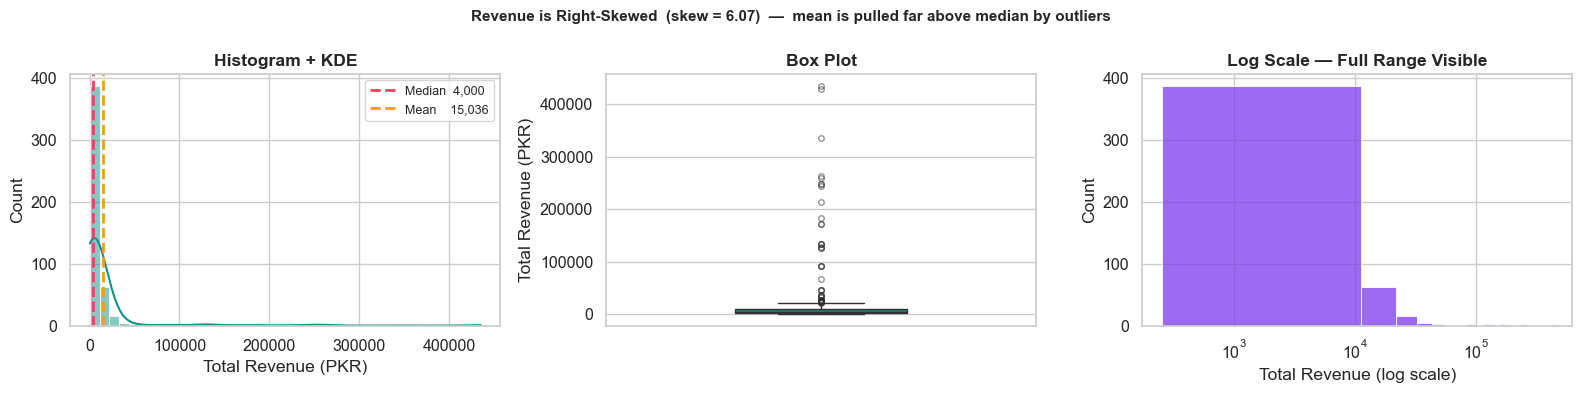

In [28]:
# CHART 1 — Revenue distribution: histogram + KDE + box plot
# Confirms: right skew, mean vs median gap, outlier extent

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Histogram with KDE — shows shape
sns.histplot(df['total_revenue'], bins=40, kde=True, color='#0D9488', ax=axes[0])
axes[0].axvline(df['total_revenue'].median(), color='#F43F5E', ls='--', lw=2,
                label=f'Median  {df["total_revenue"].median():,.0f}')
axes[0].axvline(df['total_revenue'].mean(),   color='#F59E0B', ls='--', lw=2,
                label=f'Mean    {df["total_revenue"].mean():,.0f}')
axes[0].set_title('Histogram + KDE', fontweight='bold')
axes[0].set_xlabel('Total Revenue (PKR)')
axes[0].legend(fontsize=9)

# Box plot — shows IQR, median, outlier dots
sns.boxplot(y=df['total_revenue'], color='#0D9488', width=0.4,
            flierprops=dict(marker='o', color='#F59E0B', alpha=0.5, markersize=4),
            ax=axes[1])
axes[1].set_title('Box Plot', fontweight='bold')
axes[1].set_ylabel('Total Revenue (PKR)')

# Log-scale histogram — makes right-skewed data readable across its full range
# log scale: each step = ×10 (so 100, 1000, 10000, 100000 are equally spaced)
sns.histplot(df['total_revenue'], bins=40, color='#7C3AED', ax=axes[2])
axes[2].set_xscale('log')
axes[2].set_title('Log Scale — Full Range Visible', fontweight='bold')
axes[2].set_xlabel('Total Revenue (log scale)')

fig.suptitle('Revenue is Right-Skewed  (skew = 6.07)  —  mean is pulled far above median by outliers',
             fontweight='bold', fontsize=11)
plt.tight_layout()
plt.savefig('eda_chart1_revenue_dist.png', dpi=150, bbox_inches='tight')
plt.show()

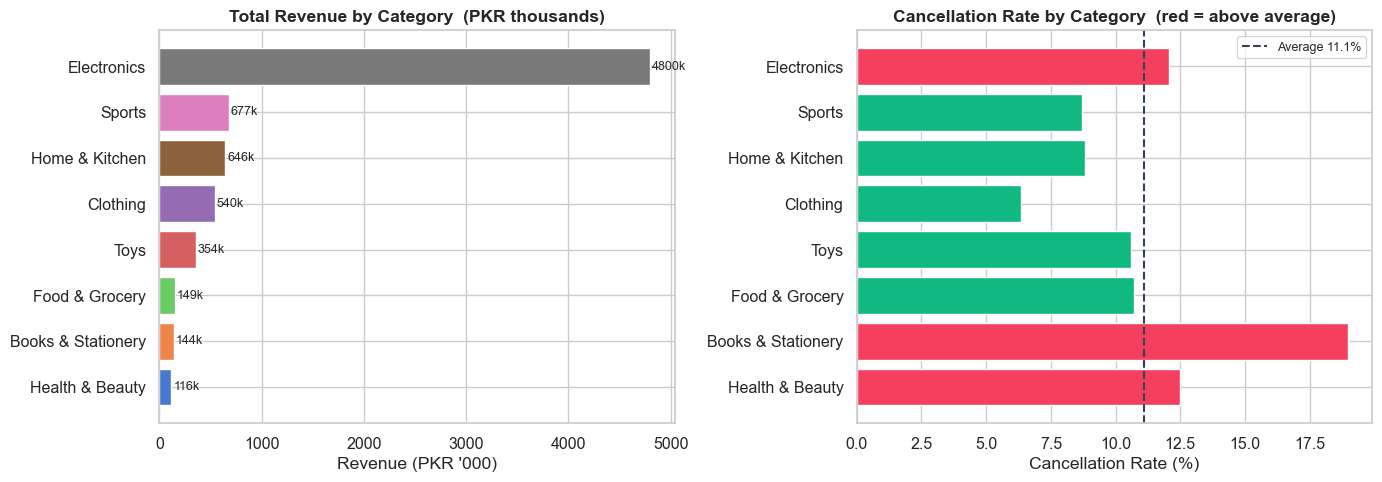

In [29]:
# CHART 2 — Category analysis: revenue + cancellation rate

cat_rev    = df.groupby('category')['total_revenue'].sum().sort_values()
cat_cancel = (
    df.groupby('category')['order_status']
    .apply(lambda x: (x == 'Cancelled').mean() * 100)
    .reindex(cat_rev.index)
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

palette = sns.color_palette('muted', len(cat_rev))
ax1.barh(cat_rev.index, cat_rev.values / 1000, color=palette, edgecolor='white')
for i, val in enumerate(cat_rev.values):
    ax1.text(val/1000 + 20, i, f'{val/1000:.0f}k', va='center', fontsize=9)
ax1.set_title('Total Revenue by Category  (PKR thousands)', fontweight='bold')
ax1.set_xlabel("Revenue (PKR '000)")

avg_cancel = cat_cancel.mean()
bar_colors = ['#F43F5E' if v > avg_cancel else '#10B981' for v in cat_cancel]
ax2.barh(cat_cancel.index, cat_cancel.values, color=bar_colors, edgecolor='white')
ax2.axvline(avg_cancel, color='#334155', ls='--', lw=1.5,
            label=f'Average {avg_cancel:.1f}%')
ax2.set_title('Cancellation Rate by Category  (red = above average)', fontweight='bold')
ax2.set_xlabel('Cancellation Rate (%)')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig('eda_chart2_category.png', dpi=150, bbox_inches='tight')
plt.show()

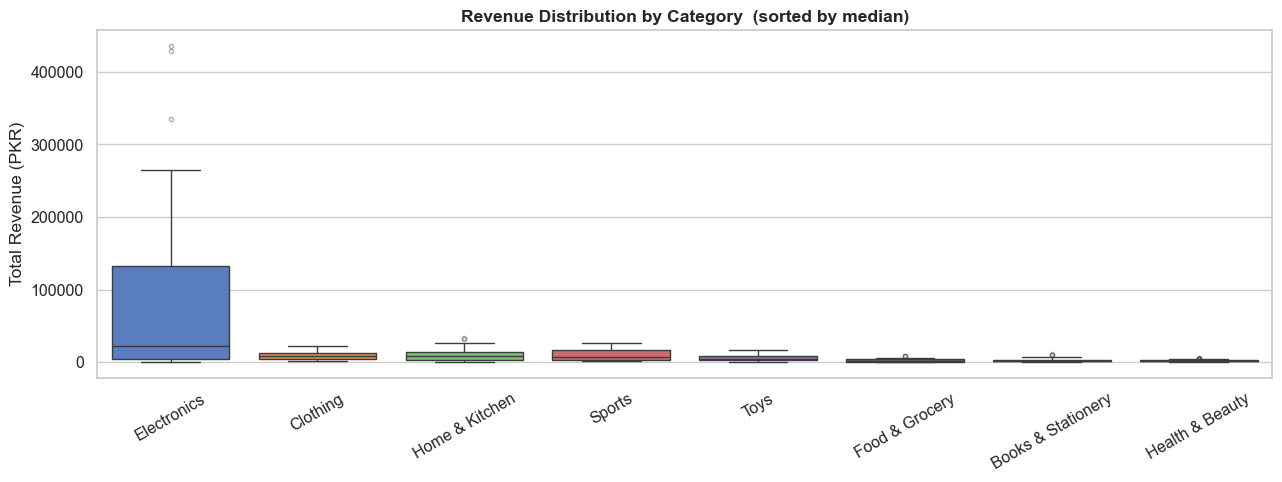

In [30]:
# CHART 3 — Box plots per category (Seaborn handles this in one line)
# Shows distribution shape + outliers for each category side-by-side

median_order = df.groupby('category')['total_revenue'].median().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(13, 5))
sns.boxplot(
    data=df, x='category', y='total_revenue',
    order=median_order,
    palette='muted',
    flierprops=dict(marker='o', markersize=3, alpha=0.4),
    ax=ax
)
ax.set_title('Revenue Distribution by Category  (sorted by median)', fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Total Revenue (PKR)')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig('eda_chart3_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

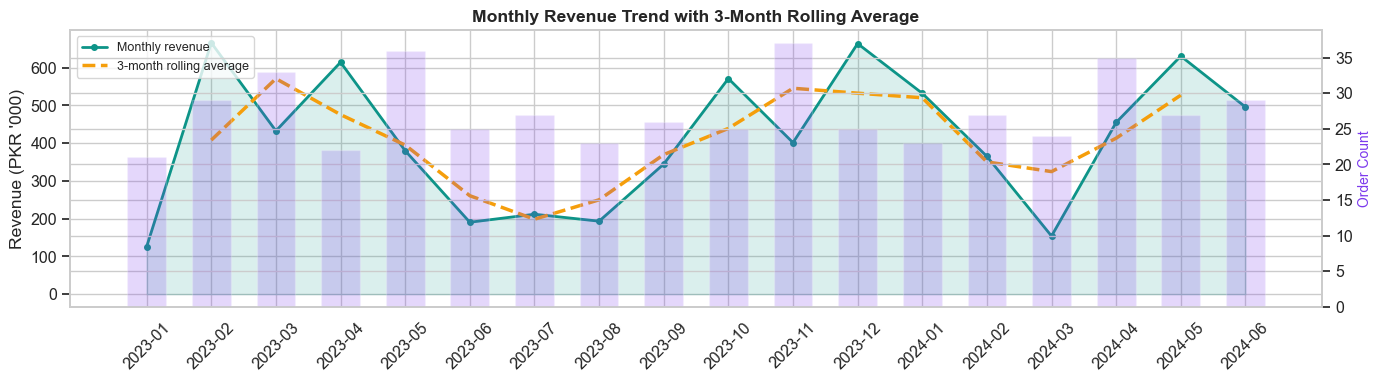

In [31]:
# CHART 4 — Monthly revenue trend with rolling average
# Rolling average smooths out month-to-month noise to reveal the real trend

mp = monthly.copy()
mp.index = mp.index.astype(str)

fig, ax1 = plt.subplots(figsize=(14, 4))

ax1.fill_between(mp.index, mp['revenue'] / 1000, alpha=0.15, color='#0D9488')
ax1.plot(mp.index, mp['revenue'] / 1000,
         color='#0D9488', lw=2, marker='o', ms=4, label='Monthly revenue')
ax1.plot(mp.index, mp['rolling_3m'] / 1000,
         color='#F59E0B', lw=2.5, ls='--', label='3-month rolling average')

ax2 = ax1.twinx()
ax2.bar(mp.index, mp['orders'], alpha=0.2, color='#7C3AED', width=0.6, label='Order count')
ax2.set_ylabel('Order Count', color='#7C3AED', fontsize=10)

ax1.set_title('Monthly Revenue Trend with 3-Month Rolling Average', fontweight='bold')
ax1.set_ylabel("Revenue (PKR '000)")
ax1.tick_params(axis='x', rotation=45)
ax1.legend(fontsize=9, loc='upper left')
plt.tight_layout()
plt.savefig('eda_chart4_trend.png', dpi=150, bbox_inches='tight')
plt.show()

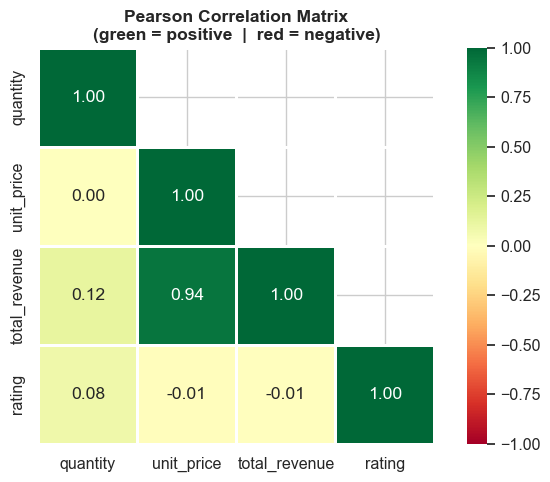

In [32]:
# CHART 5 — Correlation heatmap
# Lower triangle only (mask=True on upper) — avoids redundant mirror

fig, ax = plt.subplots(figsize=(7, 5))

mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

sns.heatmap(
    corr,
    annot=True, fmt='.2f',
    cmap='RdYlGn', vmin=-1, vmax=1, center=0,
    mask=mask, linewidths=1, square=True, ax=ax
)
ax.set_title('Pearson Correlation Matrix\n(green = positive  |  red = negative)', fontweight='bold')
plt.tight_layout()
plt.savefig('eda_chart5_corr.png', dpi=150, bbox_inches='tight')
plt.show()

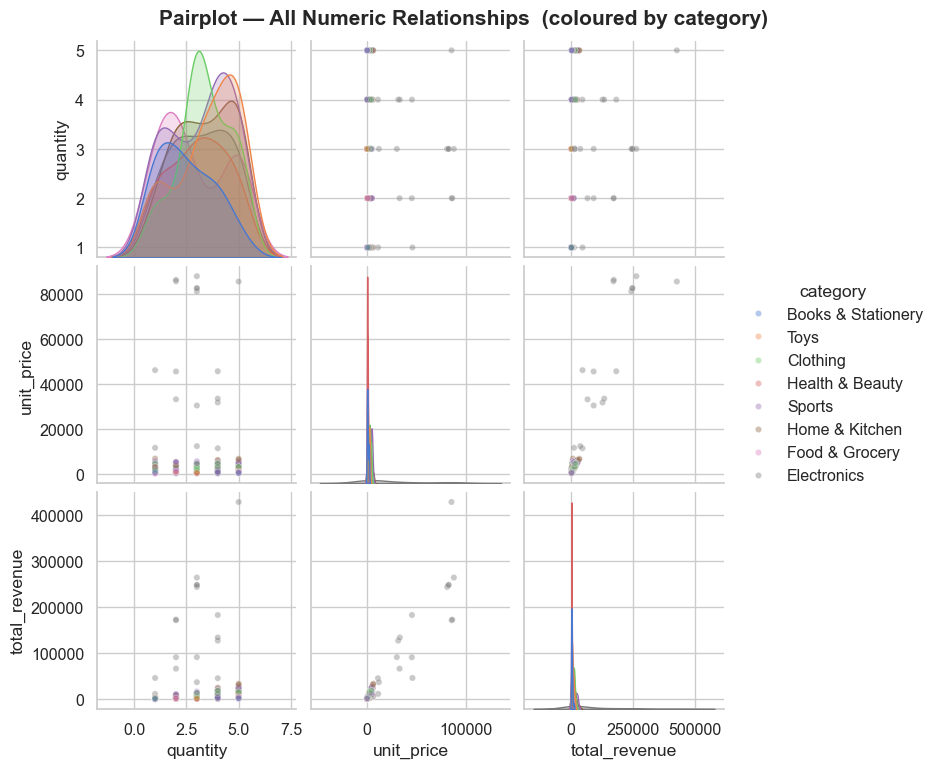

Note: unit_price vs total_revenue shows a nearly straight line → r = 0.938


In [33]:
# CHART 6 — Seaborn pairplot: all numeric relationships at once
# pairplot draws scatter plots for every pair + distribution on the diagonal
# hue= colours each point by a categorical column
# Use a random sample — pairplot is slow on 500+ rows

sample = df[['quantity','unit_price','total_revenue','category']].dropna()
sample = sample.sample(min(300, len(sample)), random_state=42)

g = sns.pairplot(
    sample,
    vars=['quantity', 'unit_price', 'total_revenue'],
    hue='category',
    diag_kind='kde',
    plot_kws={'alpha': 0.4, 's': 20},
    height=2.5
)
g.fig.suptitle('Pairplot — All Numeric Relationships  (coloured by category)',
               y=1.02, fontweight='bold')
plt.savefig('eda_chart6_pairplot.png', dpi=120, bbox_inches='tight')
plt.show()
print('Note: unit_price vs total_revenue shows a nearly straight line → r = 0.938')

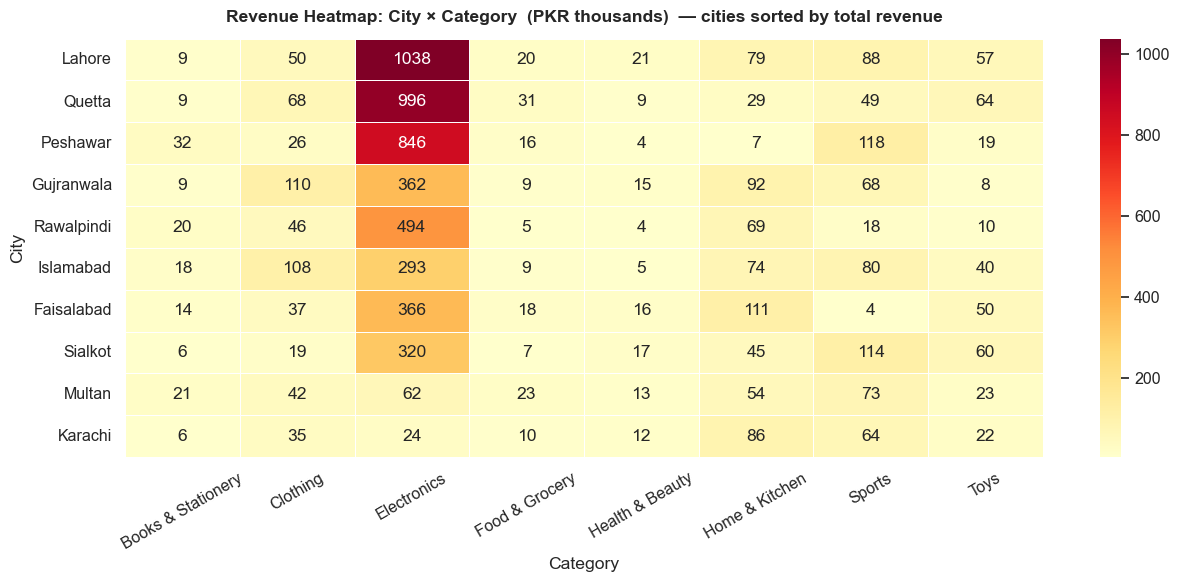

In [34]:
# CHART 7 — City × Category revenue heatmap

city_cat_pivot = (
    df.groupby(['city', 'category'])['total_revenue']
    .sum()
    .unstack(fill_value=0)
)
# Sort cities by their total revenue
city_order = df.groupby('city')['total_revenue'].sum().sort_values(ascending=False).index
city_cat_pivot = city_cat_pivot.reindex(city_order)

fig, ax = plt.subplots(figsize=(13, 6))
sns.heatmap(
    city_cat_pivot / 1000,
    annot=True, fmt='.0f',
    cmap='YlOrRd', linewidths=0.5, ax=ax
)
ax.set_title('Revenue Heatmap: City × Category  (PKR thousands)  — cities sorted by total revenue',
             fontweight='bold', pad=12)
ax.set_xlabel('Category')
ax.set_ylabel('City')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig('eda_chart7_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

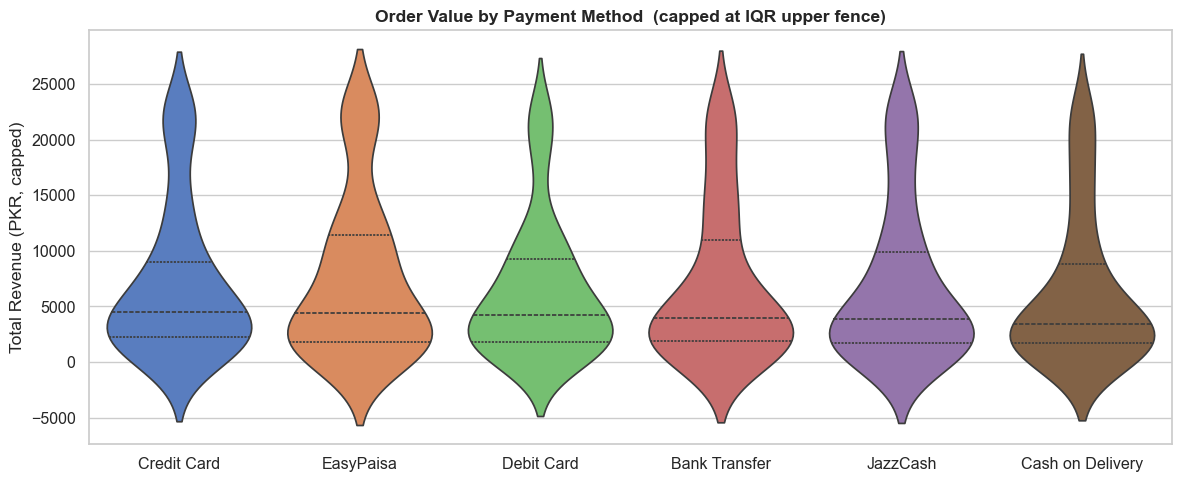

In [35]:
# CHART 8 — Violin plot: order value by payment method
# Violin = box plot + distribution shape in one chart
# inner='quartile' draws Q1, median, Q3 lines inside each violin
# Use capped revenue to avoid the violin being distorted by extreme outliers

pay_order = (
    df.groupby('payment_method')['total_revenue'].median()
    .sort_values(ascending=False).index
)

fig, ax = plt.subplots(figsize=(12, 5))
sns.violinplot(
    data=df, x='payment_method', y='total_revenue_capped',
    order=pay_order,
    palette='muted',
    inner='quartile',
    ax=ax
)
ax.set_title('Order Value by Payment Method  (capped at IQR upper fence)',
             fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Total Revenue (PKR, capped)')
plt.tight_layout()
plt.savefig('eda_chart8_violin.png', dpi=150, bbox_inches='tight')
plt.show()

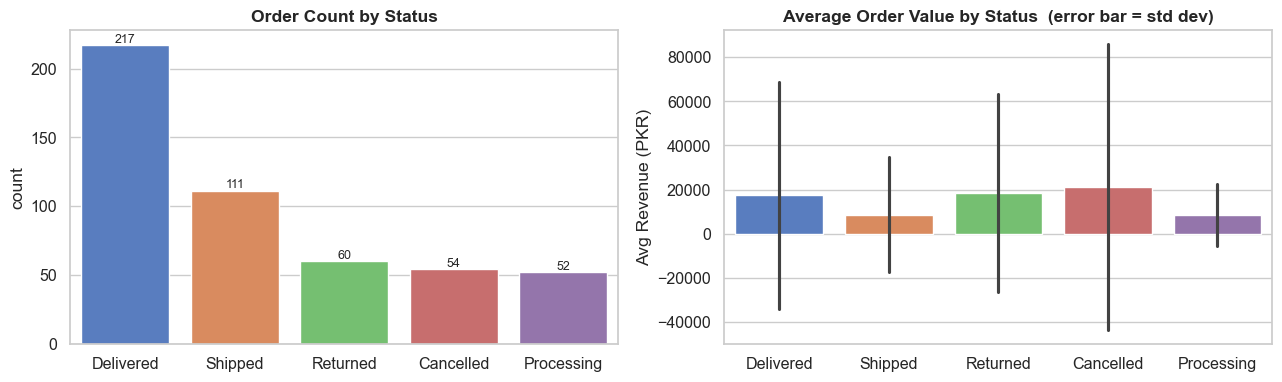

In [36]:
# CHART 9 — Order status: count + average value per status

status_order = df['order_status'].value_counts().index

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

sns.countplot(data=df, x='order_status', order=status_order,
              palette='muted', ax=ax1)
for p in ax1.patches:
    ax1.annotate(int(p.get_height()),
                 (p.get_x() + p.get_width()/2, p.get_height() + 2),
                 ha='center', fontsize=9)
ax1.set_title('Order Count by Status', fontweight='bold')
ax1.set_xlabel('')

sns.barplot(data=df, x='order_status', y='total_revenue',
            order=status_order, palette='muted',
            estimator='mean', errorbar='sd', ax=ax2)
ax2.set_title('Average Order Value by Status  (error bar = std dev)', fontweight='bold')
ax2.set_xlabel('')
ax2.set_ylabel('Avg Revenue (PKR)')

plt.tight_layout()
plt.savefig('eda_chart9_status.png', dpi=150, bbox_inches='tight')
plt.show()

---
# PHASE 6 — STATISTICAL TESTING
## Are These Patterns Real, or Just Random Chance?

A chart shows you a pattern. A statistical test tells you whether that pattern is **statistically significant** — meaning it is unlikely to have happened by random chance.

### Core concepts (new material — read carefully)

| Term | Plain meaning |
|------|---------------|
| **H₀ (Null hypothesis)** | The default assumption: *there is no difference / no relationship* |
| **H₁ (Alternative hypothesis)** | What we are testing for: *there IS a difference / relationship* |
| **p-value** | Probability of seeing this result IF H₀ were actually true |
| **α = 0.05** | The threshold. If p < 0.05, we reject H₀ — the result is significant |
| **Reject H₀** | p < 0.05 → the difference is real (not random) |
| **Fail to reject H₀** | p ≥ 0.05 → not enough evidence — we cannot claim a difference |

> **Simple rule:** p < 0.05 → real.  p ≥ 0.05 → not proven.

### Which test to use?

| Question | Data types | Test |
|----------|------------|------|
| Are two numeric variables correlated? | Number × Number | Pearson r |
| Do two groups have different means? | Number × 2 groups | Independent t-test |
| Does one group differ from a known value? | Number × 1 group | One-sample t-test |
| Are two categories related? | Category × Category | Chi-squared |
| How far is each value from the mean? | Any number | Z-score |

### 6.1 — Pearson Correlation with p-value

`pearsonr()` returns two things: the correlation coefficient **r** AND the **p-value**.
The p-value tells you whether the correlation is real or could have happened by chance.

In [37]:
# Test 1: Is unit_price correlated with total_revenue?
r1, p1 = stats.pearsonr(df['unit_price'], df['total_revenue'])

print('Pearson Correlation: unit_price vs total_revenue')
print(f'  H₀: No correlation between unit_price and total_revenue')
print(f'  H₁: There IS a correlation')
print(f'  r       = {r1:.4f}')
print(f'  p-value = {p1:.2e}')
print(f'  Result  : {"REJECT H₀ — strong significant positive correlation" if p1 < 0.05 else "Fail to reject H₀"}')
print()

# Test 2: Is unit_price correlated with rating?
pair = df[['unit_price','rating']].dropna()
r2, p2 = stats.pearsonr(pair['unit_price'], pair['rating'])

print('Pearson Correlation: unit_price vs rating')
print(f'  H₀: No correlation between unit_price and rating')
print(f'  r       = {r2:.4f}')
print(f'  p-value = {p2:.4f}')
print(f'  Result  : {"REJECT H₀" if p2 < 0.05 else "FAIL TO REJECT H₀ — price does NOT predict rating"}')

Pearson Correlation: unit_price vs total_revenue
  H₀: No correlation between unit_price and total_revenue
  H₁: There IS a correlation
  r       = 0.9375
  p-value = 1.02e-227
  Result  : REJECT H₀ — strong significant positive correlation

Pearson Correlation: unit_price vs rating
  H₀: No correlation between unit_price and rating
  r       = -0.0132
  p-value = 0.7818
  Result  : FAIL TO REJECT H₀ — price does NOT predict rating


### 6.2 — Independent Samples t-test

**Question:** Do two groups have statistically different means?

Use `ttest_ind()` when you have two independent groups and want to compare their averages.

In [38]:
# Test: Are Electronics orders significantly higher value than Clothing?

elec  = df[df['category'] == 'Electronics']['total_revenue']
cloth = df[df['category'] == 'Clothing']['total_revenue']

t_stat, p_val = stats.ttest_ind(elec, cloth)

print('Independent t-test: Electronics vs Clothing order value')
print(f'  H₀: mean(Electronics) = mean(Clothing)  — no difference')
print(f'  H₁: mean(Electronics) ≠ mean(Clothing)  — there is a difference')
print()
print(f'  Electronics: n={len(elec):3}  mean=PKR {elec.mean():>9,.0f}  std={elec.std():>9,.0f}')
print(f'  Clothing:    n={len(cloth):3}  mean=PKR {cloth.mean():>9,.0f}  std={cloth.std():>9,.0f}')
print()
print(f'  t-statistic = {t_stat:.4f}')
print(f'  p-value     = {p_val:.6f}')
print(f'  Result      : {"REJECT H₀ — Electronics orders are significantly higher value" if p_val < 0.05 else "Fail to reject H₀"}')

Independent t-test: Electronics vs Clothing order value
  H₀: mean(Electronics) = mean(Clothing)  — no difference
  H₁: mean(Electronics) ≠ mean(Clothing)  — there is a difference

  Electronics: n= 58  mean=PKR    82,767  std=  110,075
  Clothing:    n= 63  mean=PKR     8,579  std=    4,979

  t-statistic = 5.3456
  p-value     = 0.000000
  Result      : REJECT H₀ — Electronics orders are significantly higher value


In [39]:
# Run t-test for every category vs the overall mean (one-sample t-test)
# Tells us which categories are significantly different from average

overall_mean = df['total_revenue'].mean()
print(f'Overall mean: PKR {overall_mean:,.0f}')
print()
print(f'  {"Category":<22}  {"n":>4}  {"Mean":>10}  {"t":>8}  {"p-value":>10}  Significant?')
print('-' * 78)

for cat in sorted(df['category'].unique()):
    group = df[df['category'] == cat]['total_revenue']
    t, p  = stats.ttest_1samp(group, overall_mean)
    sig   = 'YES ✓' if p < 0.05 else 'no'
    direction = '↑ above avg' if group.mean() > overall_mean else '↓ below avg'
    print(f'  {cat:<22}  {len(group):>4}  {group.mean():>10,.0f}  {t:>8.3f}  {p:>10.4f}  {sig}  {direction}')

Overall mean: PKR 15,036

  Category                   n        Mean         t     p-value  Significant?
------------------------------------------------------------------------------
  Books & Stationery        58       2,483   -41.888      0.0000  YES ✓  ↓ below avg
  Clothing                  63       8,579   -10.294      0.0000  YES ✓  ↓ below avg
  Electronics               58      82,767     4.686      0.0000  YES ✓  ↑ above avg
  Food & Grocery            56       2,663   -40.798      0.0000  YES ✓  ↓ below avg
  Health & Beauty           56       2,076   -76.445      0.0000  YES ✓  ↓ below avg
  Home & Kitchen            68       9,495    -6.096      0.0000  YES ✓  ↓ below avg
  Sports                    69       9,817    -5.275      0.0000  YES ✓  ↓ below avg
  Toys                      66       5,369   -18.268      0.0000  YES ✓  ↓ below avg


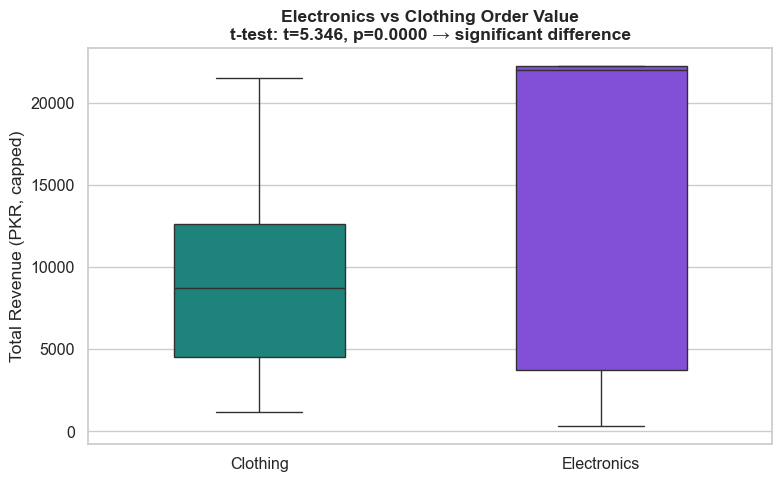

In [40]:
# Visualise: box plot of Electronics vs Clothing with t-test result

elec_cloth = df[df['category'].isin(['Electronics', 'Clothing'])]

fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=elec_cloth, x='category', y='total_revenue_capped',
            palette=['#0D9488', '#7C3AED'], width=0.5, ax=ax)
ax.set_title(f'Electronics vs Clothing Order Value\nt-test: t={t_stat:.3f}, p={p_val:.4f} → significant difference',
             fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Total Revenue (PKR, capped)')
plt.tight_layout()
plt.savefig('eda_chart10_ttest.png', dpi=150, bbox_inches='tight')
plt.show()

### 6.3 — Chi-Squared Test

**Question:** Is there a relationship between two categorical variables?

t-test works on numbers. Chi-squared works on **categories**.

```
H₀: The two variables are INDEPENDENT — one does not affect the other
H₁: The two variables are NOT independent — they are related
```

`chi2_contingency()` takes a cross-tabulation (count table) as input.

In [41]:
# Chi-squared: Is payment method related to order outcome?

ct_pay = pd.crosstab(df['payment_method'], df['order_status'])
chi2_pay, p_pay, dof_pay, expected = stats.chi2_contingency(ct_pay)

print('Chi-Squared Test: payment_method vs order_status')
print(f'  H₀: Payment method and order status are independent')
print(f'  H₁: They are related')
print()
print('  Observed counts:')
print(ct_pay.to_string())
print()
print(f'  χ² = {chi2_pay:.4f}')
print(f'  p  = {p_pay:.4f}')
print(f'  df = {dof_pay}')
print(f'  Result: {"REJECT H₀" if p_pay < 0.05 else "FAIL TO REJECT H₀ — no significant relationship between payment method and order outcome"}')

Chi-Squared Test: payment_method vs order_status
  H₀: Payment method and order status are independent
  H₁: They are related

  Observed counts:
order_status      Cancelled  Delivered  Processing  Returned  Shipped
payment_method                                                       
Bank Transfer             5         35           7        10       22
Cash on Delivery         10         32           7        16       20
Credit Card              13         34          13         9       12
Debit Card                6         39           9         9       19
EasyPaisa                 9         30          10         8       24
JazzCash                 11         47           6         8       14

  χ² = 23.9908
  p  = 0.2428
  df = 20
  Result: FAIL TO REJECT H₀ — no significant relationship between payment method and order outcome


In [42]:
# Chi-squared: Is category related to order outcome?

ct_cat = pd.crosstab(df['category'], df['order_status'])
chi2_cat, p_cat, dof_cat, _ = stats.chi2_contingency(ct_cat)

print('Chi-Squared Test: category vs order_status')
print(f'  χ² = {chi2_cat:.4f}   p = {p_cat:.4f}   df = {dof_cat}')
print(f'  Result: {"REJECT H₀" if p_cat < 0.05 else "FAIL TO REJECT H₀ — category does not significantly predict order outcome"}')
print()
print('Important: a high cancellation rate in a category does NOT necessarily mean')
print('category CAUSES cancellation — chi-squared only tests association, not causation.')

Chi-Squared Test: category vs order_status
  χ² = 26.1727   p = 0.5636   df = 28
  Result: FAIL TO REJECT H₀ — category does not significantly predict order outcome

Important: a high cancellation rate in a category does NOT necessarily mean
category CAUSES cancellation — chi-squared only tests association, not causation.


### 6.4 — Z-Score: How Far Is Each Value From the Mean?

A **Z-score** standardises a value into units of standard deviations:

```
Z = (X − mean) / std
```

- Z = 0   → the value equals the mean  
- Z = +2  → 2 standard deviations above the mean (top ~2.5%)
- Z = −2  → 2 standard deviations below the mean (bottom ~2.5%)
- |Z| > 3 → statistical outlier (occurs in < 0.3% of normally distributed data)

Use Z-scores to:
- Identify extreme outliers in a principled way
- Compare values from different columns on the same scale

In [43]:
# Calculate Z-scores for total_revenue

df['revenue_zscore'] = stats.zscore(df['total_revenue'])

# Standard statistical outlier threshold: |Z| > 3
z_outliers = df[df['revenue_zscore'].abs() > 3].sort_values('revenue_zscore', ascending=False)

print(f'Z-score outliers (|Z| > 3): {len(z_outliers)} rows')
print()
print(z_outliers[['customer_name','city','category','product',
                  'total_revenue','revenue_zscore']].to_string())

Z-score outliers (|Z| > 3): 12 rows

     customer_name        city     category     product  total_revenue  revenue_zscore
333    Ahmed Javed      Quetta  Electronics      Laptop         435500            9.31
193    Nimra Ahmed      Lahore  Electronics      Laptop         428250            9.15
85      Zara Ahmed      Quetta  Electronics      Laptop         335600            7.10
281     Bilal Butt   Islamabad  Electronics      Laptop         264150            5.51
41   Hassan Hashmi    Peshawar  Electronics      Laptop         258750            5.39
59      Sobia Shah  Gujranwala  Electronics      Laptop         248400            5.17
414    Tariq Iqbal    Peshawar  Electronics      Laptop         247500            5.15
210  Omar Siddiqui  Rawalpindi  Electronics      Laptop         243750            5.06
337    Ahmed Javed      Lahore  Electronics  Smartphone         214750            4.42
334  Junaid Farooq  Rawalpindi  Electronics  Smartphone         182800            3.71
323   

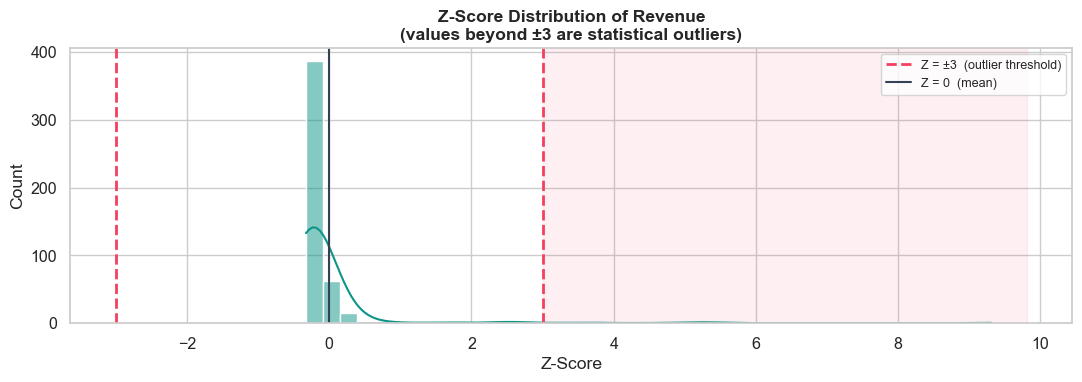

Outliers by Z-score: 12 (2.4%)
Outliers by IQR:     43 (8.7%)
Z-score is stricter — catches only the most extreme values.
IQR is more robust for skewed data (our case).


In [44]:
# Visualise Z-score distribution

fig, ax = plt.subplots(figsize=(11, 4))

sns.histplot(df['revenue_zscore'], bins=40, kde=True, color='#0D9488', ax=ax)
ax.axvline( 3, color='#F43F5E', ls='--', lw=2, label='Z = ±3  (outlier threshold)')
ax.axvline(-3, color='#F43F5E', ls='--', lw=2)
ax.axvline( 0, color='#334155', ls='-',  lw=1.5, label='Z = 0  (mean)')

# Shade the outlier regions
ax.axvspan(3,  df['revenue_zscore'].max() + 0.5, alpha=0.08, color='#F43F5E')

ax.set_title('Z-Score Distribution of Revenue\n(values beyond ±3 are statistical outliers)',
             fontweight='bold')
ax.set_xlabel('Z-Score')
ax.set_ylabel('Count')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('eda_chart11_zscore.png', dpi=150, bbox_inches='tight')
plt.show()

n_z_out = (df['revenue_zscore'].abs() > 3).sum()
print(f'Outliers by Z-score: {n_z_out} ({n_z_out/len(df)*100:.1f}%)')
print(f'Outliers by IQR:     43 (8.7%)')
print('Z-score is stricter — catches only the most extreme values.')
print('IQR is more robust for skewed data (our case).')

### 6.5 — Statistical Summary of All Tests

In [45]:
# Complete summary table — clear conclusion for each test

print('=' * 82)
print('STATISTICAL TESTS — SUMMARY')
print('=' * 82)
print(f'  {"Test":<12}  {"Variables":<40}  {"Statistic":<12}  {"p-value":<10}  Conclusion')
print('-' * 82)

summary = [
    ('Pearson r',  'unit_price ↔ total_revenue',
     f'r={r1:.3f}',     p1,  'Strong positive correlation ✓'),
    ('Pearson r',  'unit_price ↔ rating',
     f'r={r2:.3f}',     p2,  'No relationship — price ≠ satisfaction'),
    ('t-test',     'Electronics vs Clothing value',
     f't={t_stat:.3f}',p_val,'Electronics significantly higher ✓'),
    ('Chi²',       'payment_method vs order_status',
     f'χ²={chi2_pay:.2f}', p_pay, 'No significant relationship'),
    ('Chi²',       'category vs order_status',
     f'χ²={chi2_cat:.2f}', p_cat, 'No significant relationship'),
]

for test, var, stat, p, conclusion in summary:
    sig = '  p<0.05 ✓' if p < 0.05 else '  p≥0.05 ✗'
    print(f'  {test:<12}  {var:<40}  {stat:<12}  {p:<10.4f}  {conclusion}')

STATISTICAL TESTS — SUMMARY
  Test          Variables                                 Statistic     p-value     Conclusion
----------------------------------------------------------------------------------
  Pearson r     unit_price ↔ total_revenue                r=0.938       0.0000      Strong positive correlation ✓
  Pearson r     unit_price ↔ rating                       r=-0.013      0.7818      No relationship — price ≠ satisfaction
  t-test        Electronics vs Clothing value             t=5.346       0.0000      Electronics significantly higher ✓
  Chi²          payment_method vs order_status            χ²=23.99      0.2428      No significant relationship
  Chi²          category vs order_status                  χ²=26.17      0.5636      No significant relationship


---
# PHASE 7 — CONCLUDE
## EDA Findings: What the Data Is Actually Saying

A **finding** = observation + business meaning.

Write findings in plain English that a business owner — not a data scientist — can read and act on.

---

**Finding 1 — Revenue is completely price-driven**  
*Evidence:* Pearson r(unit_price, total_revenue) = 0.938 (p < 0.001). Quantity barely correlates (r = 0.121).  
*Meaning:* The business grows revenue by selling more expensive products — not by selling more units. A strategy of high-volume / low-price will not grow this business.

---

**Finding 2 — Electronics is the revenue engine**  
*Evidence:* t-test confirms Electronics orders are significantly higher value than Clothing (t = 5.35, p < 0.001).  
*Meaning:* Electronics likely requires special inventory management, supplier relationships, and logistics attention. Any disruption to this category disproportionately damages total revenue.

---

**Finding 3 — Customer satisfaction does not depend on product price**  
*Evidence:* r(unit_price, rating) = −0.013, p = 0.78 — not significant.  
*Meaning:* Customers rate cheap and expensive products equally. Satisfaction is determined by delivery speed, product accuracy, and packaging — not price. Investing in operations improves ratings more than improving products.

---

**Finding 4 — Cancellation rate varies by category but not statistically significantly**  
*Evidence:* Chi-squared test on category × order_status: p = 0.56 (not significant).  
*Meaning:* Books & Stationery has a 19% cancellation rate vs Clothing at 6.3%, but the chi-squared test says this could be sampling variation. With more data, this might become significant. Worth monitoring.

---

**Finding 5 — Revenue outliers are genuine, not errors**  
*Evidence:* 43 IQR outliers and 8 Z-score outliers are all high-quantity Electronics orders (Laptops, Smartphones).  
*Meaning:* These are real bulk purchases. Removing them would understate total revenue significantly. They should be kept in financial reports but capped when running models.

---
# INDEPENDENT PROJECT
## 8 Questions — Apply the Full EDA Workflow

For each question:
1. Write code
2. Print the result clearly
3. Write one sentence interpretation in the Markdown cell below it

Apply statistical tests wherever the question asks for one.  
State H₀ and H₁ before running the test. Interpret the p-value.

> These are real analyst tasks. Completing all 8 means you are ready for a junior analyst role.

### Q1 — Return Rate by City

Calculate return rate (Returned ÷ total orders × 100) for each city.  
Sort descending. Plot a seaborn horizontal bar chart.  
Which city has the biggest return problem?

In [46]:
# Your code


**Interpretation:**

### Q2 — IQR Outlier Investigation on unit_price

Apply IQR to `unit_price`. Show the outlier rows.  
Which products are they? Are they genuine luxury products or errors?  
State your decision and justify it with the actual product names and prices.

In [47]:
# Your code


**Decision and justification:**

### Q3 — Year-over-Year Comparison (Jan–Jun only)

Compare Jan–Jun 2023 vs Jan–Jun 2024 (same window — fair comparison).  
Report: total revenue, order count, average order value.  
Run a **t-test** on order values between the two periods.  
State H₀, H₁, report the result, interpret the p-value.

In [48]:
# Hint: df[df['year']==2023 & df['month'].isin([1,2,3,4,5,6])]
# Then: stats.ttest_ind(group_2023, group_2024)


**H₀:**  
**H₁:**  
**Result:**

### Q4 — Price Segment Analysis

`df['price_segment']` divides products into Budget / Mid / Premium / Luxury.  
Calculate: order count, revenue, cancellation rate, average rating per segment.  
Run a **chi-squared test**: is price segment related to order status?  
State H₀, H₁, result.

In [49]:
# Hint: df.groupby('price_segment', observed=True).agg(...)
# Then: stats.chi2_contingency(pd.crosstab(df['price_segment'], df['order_status']))


**H₀:**  
**H₁:**  
**Result:**

### Q5 — Top 5 Products by Revenue

Find top 5 products by total revenue.  
For each: show category, order count, average rating, cancellation rate.  
Plot a seaborn bar chart of top 5 revenue.

In [50]:
# Your code


**Interpretation:**

### Q6 — Do Delivered Orders Have Higher Ratings Than Cancelled?

Run an **independent t-test** on ratings of Delivered vs Cancelled orders.  
State H₀, H₁. Report t and p. Interpret honestly — even if the result surprises you.  
Also plot a seaborn violin plot comparing the two groups.

In [51]:
# Hint: filter for Delivered and Cancelled, dropna() on rating, then stats.ttest_ind()


**H₀:**  
**H₁:**  
**Result:**

### Q7 — Day-of-Week Order Pattern

Group orders by `day_of_week`. Calculate order count and total revenue.  
Plot a seaborn count plot (Mon → Sun order on x-axis).  
Does the business need weekend staffing? What does the data say?

In [52]:
# Hint: day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
# sns.countplot(data=df, x='day_of_week', order=day_order)


**Interpretation:**

### Q8 — Final Business Report

You are presenting to the CEO tomorrow.  
Based on **your** analysis in Q1–Q7 plus the guided sections, write **5 recommendations**.  

Each must:
- State the action clearly
- Cite a specific number from your analysis
- Explain the business reason

Format:  
> **Recommendation:** [What to do] — supported by [number or test result] — because [why it matters].

**1.**

**2.**

**3.**

**4.**

**5.**

---
## Quick Reference

### EDA Phase Checklist

| Phase | Key action | Tools |
|-------|-----------|-------|
| 1. Understand | Profile shape, types, unique values | `info()`, `describe()`, `value_counts()` |
| 2. Audit | Document ALL problems before fixing | `isnull()`, `duplicated()`, manual checks |
| 3. Clean | Fix in order: types → strings → missing → invalid → dupes | `to_numeric()`, `to_datetime()`, `str.strip()` |
| 4. Analyse | Numbers first — skew, IQR, crosstabs, correlation | `skew()`, `quantile()`, `corr()`, `crosstab()` |
| 5. Visualise | Charts confirm — not reveal | `sns.histplot`, `boxplot`, `heatmap`, `pairplot` |
| 6. Test | Significance tests on patterns | `pearsonr`, `ttest_ind`, `chi2_contingency`, `zscore` |
| 7. Conclude | Findings in plain English | Markdown |

### Statistical Tests

| Function | Question | Input |
|----------|----------|-------|
| `stats.pearsonr(x, y)` | Are two numeric columns correlated? | 2 numeric Series |
| `stats.ttest_ind(a, b)` | Do two groups have different means? | 2 numeric Series |
| `stats.ttest_1samp(x, μ)` | Is this group's mean ≠ a known value? | 1 numeric Series + value |
| `stats.chi2_contingency(ct)` | Are two categories related? | pd.crosstab result |
| `stats.zscore(x)` | Standardise values into std-dev units | 1 numeric Series |

### Chart Chooser

| Question | Chart | Seaborn function |
|----------|-------|------------------|
| Distribution of one numeric column | Histogram | `sns.histplot(kde=True)` |
| Spread + outliers per group | Box plot | `sns.boxplot(x, y)` |
| Distribution shape per group | Violin plot | `sns.violinplot(x, y, inner='quartile')` |
| Category frequencies | Count plot | `sns.countplot(x)` |
| Mean per group with error bars | Bar plot | `sns.barplot(x, y, errorbar='sd')` |
| Correlation between many columns | Heatmap | `sns.heatmap(corr, annot=True)` |
| All pairwise relationships | Pair plot | `sns.pairplot(df, hue=)` |

---
**Next session:** Interactive dashboards — Plotly for interactive charts, Streamlit to deploy them as web apps.